In [1]:
import os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
RAW = os.path.join(PROJECT_ROOT, "data/raw")
PROC = os.path.join(PROJECT_ROOT, "data/processed")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
print("Project root:", PROJECT_ROOT)

Project root: f:\BRACU\CSE425\Project\gnn-bert-music-context


In [ ]:
# ============================================================
# CELL 1 — Setup
# ============================================================
import os, glob, json, random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score
from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch.optim import Adam


os.makedirs(os.path.join(RESULTS_DIR, "plots"), exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

d:\Program Files\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [ ]:
# ============================================================
# CELL 2 — Load FMA graphs + labels 
# ============================================================
fma_labels = pd.read_csv(os.path.join(PROC, "fma_small_labels_final.csv"))
genres = sorted(fma_labels["genre"].unique())
genre_to_idx = {g: i for i, g in enumerate(genres)}
print(genre_to_idx)

FMA_GRAPH_DIR = os.path.join(PROC, "fma_graphs")
dataset = []
for _, row in tqdm(fma_labels.iterrows(), total=len(fma_labels)):
    graph = torch.load(os.path.join(FMA_GRAPH_DIR, f"{row['track_id']}.pt"), weights_only=False)
    graph.y = torch.tensor([genre_to_idx[row["genre"]]], dtype=torch.long)
    dataset.append(graph)

print("Total graphs loaded:", len(dataset))

{'Electronic': 0, 'Experimental': 1, 'Folk': 2, 'Hip-Hop': 3, 'Instrumental': 4, 'International': 5, 'Pop': 6, 'Rock': 7}


100%|██████████| 7994/7994 [02:29<00:00, 53.57it/s]

Total graphs loaded: 7994


In [3]:
# ============================================================
# CELL 3 — Split, model, train
# ============================================================
random.seed(42)
indices = list(range(len(dataset)))
random.shuffle(indices)
n = len(indices)
train_end, val_end = int(0.8*n), int(0.9*n)
train_data = [dataset[i] for i in indices[:train_end]]
val_data = [dataset[i] for i in indices[train_end:val_end]]
test_data = [dataset[i] for i in indices[val_end:]]
print("Train:", len(train_data), "| Val:", len(val_data), "| Test:", len(test_data))

class GraphSAGEClassifier(nn.Module):
    def __init__(self, in_channels=12, hidden_channels=64, num_classes=8, num_layers=2):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.classifier = nn.Linear(hidden_channels, num_classes)
    def forward(self, x, edge_index, batch):
        for conv in self.convs:
            x = F.relu(conv(x, edge_index))
        g = global_mean_pool(x, batch)
        return self.classifier(g)

gnn_model = GraphSAGEClassifier(in_channels=12, num_classes=len(genres)).to(device)

BATCH_SIZE = 64
train_loader = PyGDataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader_gnn = PyGDataLoader(val_data, batch_size=BATCH_SIZE)
test_loader_gnn = PyGDataLoader(test_data, batch_size=BATCH_SIZE)

criterion_gnn = nn.CrossEntropyLoss()
optimizer_gnn = Adam(gnn_model.parameters(), lr=0.001)

def evaluate_gnn(loader):
    gnn_model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = gnn_model(batch.x, batch.edge_index, batch.batch)
            loss = criterion_gnn(logits, batch.y)
            total_loss += loss.item()
            all_preds.append(logits.argmax(dim=1).cpu().numpy())
            all_labels.append(batch.y.cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return (total_loss/len(loader), accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average="macro", zero_division=0))

gnn_history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_macro_f1": []}
for epoch in range(15):
    gnn_model.train()
    train_loss = 0
    for batch in tqdm(train_loader, desc=f"GNN Epoch {epoch+1}", leave=False):
        batch = batch.to(device)
        optimizer_gnn.zero_grad()
        logits = gnn_model(batch.x, batch.edge_index, batch.batch)
        loss = criterion_gnn(logits, batch.y)
        loss.backward()
        optimizer_gnn.step()
        train_loss += loss.item()
    val_loss, val_acc, val_macro_f1 = evaluate_gnn(val_loader_gnn)
    gnn_history["train_loss"].append(train_loss/len(train_loader))
    gnn_history["val_loss"].append(val_loss)
    gnn_history["val_acc"].append(val_acc)
    gnn_history["val_macro_f1"].append(val_macro_f1)
    print(f"Epoch {epoch+1}: train_loss={train_loss/len(train_loader):.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_macro_f1={val_macro_f1:.4f}")

Train: 6395 | Val: 799 | Test: 800


Epoch 1: train_loss=2.0317 | val_loss=1.9685 | val_acc=0.2078 | val_macro_f1=0.1114


Epoch 2: train_loss=1.9315 | val_loss=1.9103 | val_acc=0.2516 | val_macro_f1=0.1884


Epoch 3: train_loss=1.9004 | val_loss=1.8930 | val_acc=0.2854 | val_macro_f1=0.2447


Epoch 4: train_loss=1.8817 | val_loss=1.8825 | val_acc=0.2816 | val_macro_f1=0.2309


...

Epoch 11: train_loss=1.8096 | val_loss=1.8382 | val_acc=0.2979 | val_macro_f1=0.2593


Epoch 12: train_loss=1.8078 | val_loss=1.8400 | val_acc=0.2866 | val_macro_f1=0.2477


Epoch 13: train_loss=1.8013 | val_loss=1.8253 | val_acc=0.2966 | val_macro_f1=0.2740


Epoch 14: train_loss=1.7979 | val_loss=1.8415 | val_acc=0.2929 | val_macro_f1=0.2663


Epoch 15: train_loss=1.7919 | val_loss=1.8206 | val_acc=0.3041 | val_macro_f1=0.2826


In [4]:
# ============================================================
# CELL 4 — GNN test + save
# ============================================================
test_loss_gnn, test_acc_gnn, test_macro_f1_gnn = evaluate_gnn(test_loader_gnn)
print(f"GNN TEST: loss={test_loss_gnn:.4f} | acc={test_acc_gnn:.4f} | macro_f1={test_macro_f1_gnn:.4f}")
torch.save(gnn_model.state_dict(), os.path.join(RESULTS_DIR, "task2_gnn_model.pt"))
with open(os.path.join(RESULTS_DIR, "task2_gnn_history.json"), "w") as f:
    json.dump(gnn_history, f, indent=2)

GNN TEST: loss=1.8601 | acc=0.2888 | macro_f1=0.2679


In [5]:
# ============================================================
# CELL 5 — Extract mel-spectrograms for all FMA tracks
# ============================================================
MEL_DIR = os.path.join(PROC, "fma_mel_specs")
os.makedirs(MEL_DIR, exist_ok=True)

def extract_mel_spec(mp3_path, sr=22050, n_mels=128, fixed_frames=1300):
    y, _ = librosa.load(mp3_path, sr=sr)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    if mel_db.shape[1] < fixed_frames:
        mel_db = np.pad(mel_db, ((0,0),(0, fixed_frames - mel_db.shape[1])), mode='constant', constant_values=mel_db.min())
    else:
        mel_db = mel_db[:, :fixed_frames]
    return mel_db.astype(np.float32)

MEL_MANIFEST_PATH = os.path.join(PROC, "fma_mel_manifest.csv")
if os.path.exists(MEL_MANIFEST_PATH):
    mel_manifest = pd.read_csv(MEL_MANIFEST_PATH)
else:
    mel_manifest = pd.DataFrame(columns=["track_id", "success", "error"])
done_mel_ids = set(mel_manifest["track_id"])

all_mp3s = glob.glob(os.path.join(RAW, "fma", "fma_small", "**", "*.mp3"), recursive=True)
new_rows = []
for mp3_path in tqdm(all_mp3s):
    track_id = int(os.path.basename(mp3_path).replace(".mp3", ""))
    if track_id in done_mel_ids:
        continue
    try:
        mel = extract_mel_spec(mp3_path)
        np.save(os.path.join(MEL_DIR, f"{track_id}.npy"), mel)
        new_rows.append({"track_id": track_id, "success": True, "error": ""})
    except Exception as e:
        new_rows.append({"track_id": track_id, "success": False, "error": str(e)[:200]})
    done_mel_ids.add(track_id)

mel_manifest = pd.concat([mel_manifest, pd.DataFrame(new_rows)]).drop_duplicates(subset="track_id", keep="last")
mel_manifest.to_csv(MEL_MANIFEST_PATH, index=False)
print(mel_manifest["success"].value_counts())

100%|██████████| 8000/8000 [14:54<00:00,  8.94it/s] 

success
True     7994
False       6
Name: count, dtype: int64


In [6]:
# ============================================================
# CELL 6 — CNN model + dataset + training
# ============================================================
from torch.utils.data import Dataset, DataLoader

class GenreCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(64, num_classes)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.global_pool(x)
        return self.classifier(x.view(x.size(0), -1))

class MelSpectrogramDataset(Dataset):
    def __init__(self, labels_df, mel_dir, genre_to_idx):
        self.labels_df = labels_df.reset_index(drop=True)
        self.mel_dir = mel_dir
        self.genre_to_idx = genre_to_idx
    def __len__(self):
        return len(self.labels_df)
    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        mel = np.load(os.path.join(self.mel_dir, f"{row['track_id']}.npy"))
        return torch.tensor(mel, dtype=torch.float).unsqueeze(0), self.genre_to_idx[row["genre"]]

successful_mel_ids = set(mel_manifest[mel_manifest["success"] == True]["track_id"])
fma_labels_cnn = fma_labels[fma_labels["track_id"].isin(successful_mel_ids)].reset_index(drop=True)
print("Tracks with valid mel:", len(fma_labels_cnn))

random.seed(42)
indices = list(range(len(fma_labels_cnn)))
random.shuffle(indices)
n = len(indices)
train_end, val_end = int(0.8*n), int(0.9*n)
train_labels_cnn = fma_labels_cnn.iloc[indices[:train_end]]
val_labels_cnn = fma_labels_cnn.iloc[indices[train_end:val_end]]
test_labels_cnn = fma_labels_cnn.iloc[indices[val_end:]]

train_loader_cnn = DataLoader(MelSpectrogramDataset(train_labels_cnn, MEL_DIR, genre_to_idx), batch_size=32, shuffle=True)
val_loader_cnn = DataLoader(MelSpectrogramDataset(val_labels_cnn, MEL_DIR, genre_to_idx), batch_size=32)
test_loader_cnn = DataLoader(MelSpectrogramDataset(test_labels_cnn, MEL_DIR, genre_to_idx), batch_size=32)

cnn_model = GenreCNN(num_classes=8).to(device)
criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = Adam(cnn_model.parameters(), lr=0.001)

def evaluate_cnn(loader):
    cnn_model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for mels, labels in loader:
            mels, labels = mels.to(device), labels.to(device)
            logits = cnn_model(mels)
            total_loss += criterion_cnn(logits, labels).item()
            all_preds.append(logits.argmax(dim=1).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return (total_loss/len(loader), accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average="macro", zero_division=0))

cnn_history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_macro_f1": []}
for epoch in range(15):
    cnn_model.train()
    train_loss = 0
    for mels, labels in tqdm(train_loader_cnn, desc=f"CNN Epoch {epoch+1}", leave=False):
        mels, labels = mels.to(device), labels.to(device)
        optimizer_cnn.zero_grad()
        logits = cnn_model(mels)
        loss = criterion_cnn(logits, labels)
        loss.backward()
        optimizer_cnn.step()
        train_loss += loss.item()
    val_loss, val_acc, val_macro_f1 = evaluate_cnn(val_loader_cnn)
    cnn_history["train_loss"].append(train_loss/len(train_loader_cnn))
    cnn_history["val_loss"].append(val_loss)
    cnn_history["val_acc"].append(val_acc)
    cnn_history["val_macro_f1"].append(val_macro_f1)
    print(f"Epoch {epoch+1}: train_loss={train_loss/len(train_loader_cnn):.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_macro_f1={val_macro_f1:.4f}")

Tracks with valid mel: 7994


Epoch 1: train_loss=1.9862 | val_loss=1.7747 | val_acc=0.3016 | val_macro_f1=0.2539


Epoch 2: train_loss=1.7484 | val_loss=1.6889 | val_acc=0.3817 | val_macro_f1=0.3343


Epoch 3: train_loss=1.6235 | val_loss=1.5564 | val_acc=0.4468 | val_macro_f1=0.4384


Epoch 4: train_loss=1.5516 | val_loss=1.5224 | val_acc=0.4618 | val_macro_f1=0.4423


...

Epoch 11: train_loss=1.3203 | val_loss=1.3652 | val_acc=0.5257 | val_macro_f1=0.5079


Epoch 12: train_loss=1.3235 | val_loss=1.3303 | val_acc=0.5519 | val_macro_f1=0.5490


Epoch 13: train_loss=1.2869 | val_loss=1.3106 | val_acc=0.5407 | val_macro_f1=0.5373


Epoch 14: train_loss=1.2908 | val_loss=1.3707 | val_acc=0.5332 | val_macro_f1=0.5127


Epoch 15: train_loss=1.2781 | val_loss=1.2902 | val_acc=0.5394 | val_macro_f1=0.5233


CNN TEST: loss=1.3080 | acc=0.5537 | macro_f1=0.5440


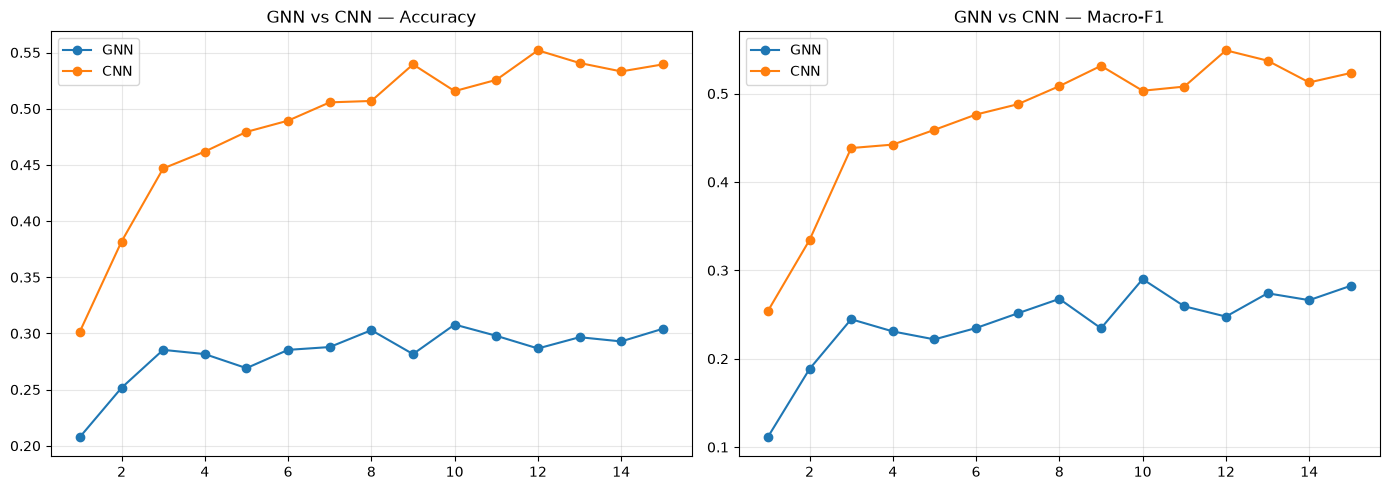

In [7]:
# ============================================================
# CELL 7 — CNN test + save + comparison plot
# ============================================================
import matplotlib.pyplot as plt

test_loss_cnn, test_acc_cnn, test_macro_f1_cnn = evaluate_cnn(test_loader_cnn)
print(f"CNN TEST: loss={test_loss_cnn:.4f} | acc={test_acc_cnn:.4f} | macro_f1={test_macro_f1_cnn:.4f}")
torch.save(cnn_model.state_dict(), os.path.join(RESULTS_DIR, "task2_cnn_model.pt"))
with open(os.path.join(RESULTS_DIR, "task2_cnn_history.json"), "w") as f:
    json.dump(cnn_history, f, indent=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, 16), gnn_history["val_acc"], marker='o', label="GNN")
axes[0].plot(range(1, 16), cnn_history["val_acc"], marker='o', label="CNN")
axes[0].set_title("GNN vs CNN — Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(range(1, 16), gnn_history["val_macro_f1"], marker='o', label="GNN")
axes[1].plot(range(1, 16), cnn_history["val_macro_f1"], marker='o', label="CNN")
axes[1].set_title("GNN vs CNN — Macro-F1"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "plots/task2_gnn_vs_cnn.png"), dpi=150)
plt.show()

In [ ]:
import os, glob, random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import label_binarize

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
PROC = os.path.join(PROJECT_ROOT, "data/processed")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

fma_labels = pd.read_csv(os.path.join(PROC, "fma_small_labels_final.csv"))
genres = sorted(fma_labels["genre"].unique())
genre_to_idx = {g: i for i, g in enumerate(genres)}

FMA_GRAPH_DIR = os.path.join(PROC, "fma_graphs")
dataset = []
for _, row in fma_labels.iterrows():
    graph = torch.load(os.path.join(FMA_GRAPH_DIR, f"{row['track_id']}.pt"), weights_only=False)
    graph.y = torch.tensor([genre_to_idx[row["genre"]]], dtype=torch.long)
    dataset.append(graph)

random.seed(42)
indices = list(range(len(dataset)))
random.shuffle(indices)
n = len(indices)
train_end, val_end = int(0.8*n), int(0.9*n)
test_data = [dataset[i] for i in indices[val_end:]]
test_loader_gnn = PyGDataLoader(test_data, batch_size=64)
print("GNN test set:", len(test_data))


class GraphSAGEClassifier(nn.Module):
    def __init__(self, in_channels=12, hidden_channels=64, num_classes=8, num_layers=2):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.classifier = nn.Linear(hidden_channels, num_classes)
    def forward(self, x, edge_index, batch):
        for conv in self.convs:
            x = F.relu(conv(x, edge_index))
        g = global_mean_pool(x, batch)
        return self.classifier(g)

gnn_model = GraphSAGEClassifier(in_channels=12, num_classes=8).to(device)
gnn_model.load_state_dict(torch.load(os.path.join(RESULTS_DIR, "task2_gnn_model.pt"), map_location=device))
gnn_model.eval()
print("GNN model reloaded.")

d:\Program Files\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GNN test set: 800
GNN model reloaded.


C:\Users\zawad\AppData\Local\Temp\ipykernel_20420\1833801546.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gnn_model.load_state_dict(torch.load(os.path.join(RESULTS_D

In [6]:
# --- GNN AUC-PR ---
all_probs_gnn, all_labels_gnn = [], []
with torch.no_grad():
    for batch in test_loader_gnn:
        batch = batch.to(device)
        logits = gnn_model(batch.x, batch.edge_index, batch.batch)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        all_probs_gnn.append(probs)
        all_labels_gnn.append(batch.y.cpu().numpy())
all_probs_gnn = np.concatenate(all_probs_gnn)
all_labels_gnn = np.concatenate(all_labels_gnn)

y_true_bin = label_binarize(all_labels_gnn, classes=list(range(8)))
auc_pr_gnn = np.mean([average_precision_score(y_true_bin[:, i], all_probs_gnn[:, i]) for i in range(8)])
print("Task 2 GNN mean AUC-PR:", auc_pr_gnn)

Task 2 GNN mean AUC-PR: 0.2726206796384403


In [7]:
class GenreCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(64, num_classes)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.global_pool(x)
        return self.classifier(x.view(x.size(0), -1))

class MelSpectrogramDataset(Dataset):
    def __init__(self, labels_df, mel_dir, genre_to_idx):
        self.labels_df = labels_df.reset_index(drop=True)
        self.mel_dir = mel_dir
        self.genre_to_idx = genre_to_idx
    def __len__(self):
        return len(self.labels_df)
    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        mel = np.load(os.path.join(self.mel_dir, f"{row['track_id']}.npy"))
        return torch.tensor(mel, dtype=torch.float).unsqueeze(0), self.genre_to_idx[row["genre"]]

mel_manifest = pd.read_csv(os.path.join(PROC, "fma_mel_manifest.csv"))
successful_mel_ids = set(mel_manifest[mel_manifest["success"] == True]["track_id"])
fma_labels_cnn = fma_labels[fma_labels["track_id"].isin(successful_mel_ids)].reset_index(drop=True)

random.seed(42)
indices = list(range(len(fma_labels_cnn)))
random.shuffle(indices)
n = len(indices)
train_end, val_end = int(0.8*n), int(0.9*n)
test_labels_cnn = fma_labels_cnn.iloc[indices[val_end:]]

MEL_DIR = os.path.join(PROC, "fma_mel_specs")
test_loader_cnn = DataLoader(MelSpectrogramDataset(test_labels_cnn, MEL_DIR, genre_to_idx), batch_size=32)

cnn_model = GenreCNN(num_classes=8).to(device)
cnn_model.load_state_dict(torch.load(os.path.join(RESULTS_DIR, "task2_cnn_model.pt"), map_location=device))
cnn_model.eval()

all_probs_cnn, all_labels_cnn = [], []
with torch.no_grad():
    for mels, labels in test_loader_cnn:
        mels = mels.to(device)
        probs = F.softmax(cnn_model(mels), dim=1).cpu().numpy()
        all_probs_cnn.append(probs)
        all_labels_cnn.append(labels.numpy())
all_probs_cnn = np.concatenate(all_probs_cnn)
all_labels_cnn = np.concatenate(all_labels_cnn)

y_true_bin_cnn = label_binarize(all_labels_cnn, classes=list(range(8)))
auc_pr_cnn = np.mean([average_precision_score(y_true_bin_cnn[:, i], all_probs_cnn[:, i]) for i in range(8)])
print("Task 2 CNN mean AUC-PR:", auc_pr_cnn)

C:\Users\zawad\AppData\Local\Temp\ipykernel_20420\3959979773.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cnn_model.load_state_dict(torch.load(os.path.join(RESULTS_D

Task 2 CNN mean AUC-PR: 0.598632069249006


In [4]:
train_labels_cnn.to_csv(os.path.join(PROJECT_ROOT, "data/splits/fma_train.csv"), index=False)
val_labels_cnn.to_csv(os.path.join(PROJECT_ROOT, "data/splits/fma_val.csv"), index=False)
test_labels_cnn.to_csv(os.path.join(PROJECT_ROOT, "data/splits/fma_test.csv"), index=False)
print("FMA splits saved.")

FMA splits saved.
